Simple Version

In [ ]:
import numpy as np
np.random.seed(42)


class LogisticRegression:
    def __init__(self, lr=1e-2, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # initialize weights and bias
        self.weights = np.random.randn(n_features)
        self.bias = 0.0
        
        for _ in range(self.n_iters):
            # compute linear combination (z = Xw + b)
            z = np.dot(X, self.weights) + self.bias
            # apply _sigmoid activation to get predicted probabilities
            y_pred = self._sigmoid(z)
            # https://www.geeksforgeeks.org/machine-learning/derivative-of-the-sigmoid-function/
            dw = (1/n_samples) * np.dot(X.T, y_pred-y)
            db = (1/n_samples) * np.sum(y_pred-y)
            # update weights and bias using learning rate
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict(self, X):
        # compute linear combination (z = Xw + b)
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        return np.round(y_pred).astype(int)

In [17]:
# create sample dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression()

# train model on sample dataset
lr.fit(X, y)

# make predictions on new data
X_new = np.array([[6, 7], [7, 8]])
y_pred = lr.predict(X_new)

print(y_pred)  # [1, 1]

[1 1]


In [ ]:
np.array_split(X, np.ceil(len(X)/4))

[array([[1, 2],
        [2, 3]]),
 array([[3, 4]]),
 array([[4, 5]]),
 array([[5, 6]])]

In [36]:
np.array_split(X, np.ceil(len(X)/2))

[array([[1, 2],
        [2, 3]]),
 array([[3, 4],
        [4, 5]]),
 array([[5, 6]])]

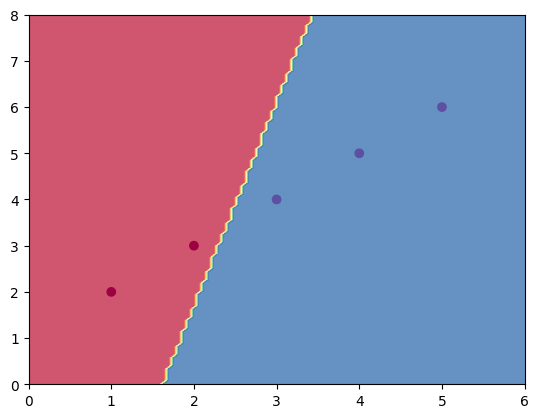

In [25]:
import matplotlib.pyplot as plt

X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression(lr=0.1, n_iters=1000)
lr.fit(X, y)

# plot decision boundary
x1 = np.linspace(0, 6, 100)
x2 = np.linspace(0, 8, 100)
xx, yy = np.meshgrid(x1, x2)
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# plot data points
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)
plt.show()

Improvements

1. Add regularization: Regularization can help prevent overfitting and improve the generalization performance of the model. You could add L1 or L2 regularization to the cost function and adjust the regularization strength with a hyperparameter.
2. Use a more sophisticated optimization algorithm: Gradient descent is a simple and effective optimization algorithm, but it may not be the most efficient or accurate for large or complex datasets. You could try using a more sophisticated algorithm, such as stochastic gradient descent (SGD), mini-batch SGD, or Adam, which can converge faster and find better optima. Here's an example of how to use mini-batch SGD:

In [ ]:
np.arrange(-1,)

array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [8, 9]])

In [94]:
import numpy as np
np.random.seed(42)


class LogisticRegression:
    def __init__(self, lr=1e-2, n_iters=1000, reg_type = 'l2', reg_strength = 0.01, optimizer = 'sgd', batch_size =2):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        # optimization
        self.reg_type = reg_type
        self.reg_strength = reg_strength
        self.batch_size = batch_size
        self.optimizer = optimizer
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # initialize weights and bias
        self.weights = np.random.randn(n_features)
        self.bias = 0.0
        
        idxs = np.arange(n_samples) 
        
        for i in range(self.n_iters):
            # batching: sample randomly with replacement
            batch_idxs = np.random.choice(n_samples, self.batch_size, replace=True)
            X_b, y_b = X[batch_idxs], y[batch_idxs]

            # regular calculation
            z = np.dot(X_b, self.weights) + self.bias
            y_pred = self._sigmoid(z)
            dw = (1/self.batch_size) * np.dot(X_b.T, (y_pred-y_b))
            db = (1/self.batch_size) * np.sum(y_pred-y_b)

            # regularization
            if self.reg_type == 'l2':
                dw += self.reg_strength * self.weights 
            elif self.reg_type == 'l1':
                dw += self.reg_strength * np.sign(self.weights)
            elif self.reg_type == 'elastic':
                alpha = 0.5
                dw += self.reg_strength * (alpha * np.sign(self.weights) + (1 - alpha) * self.weights)

            # regular weight update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            
    def predict(self, X):
        # compute linear combination (z = Xw + b)
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        return np.round(y_pred).astype(int)

In [95]:
# create sample dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression()

# train model on sample dataset
lr.fit(X, y)

# make predictions on new data
X_new = np.array([[6, 7], [7, 8]])
y_pred = lr.predict(X_new)

print(y_pred)  # [1, 1]

[1 1]


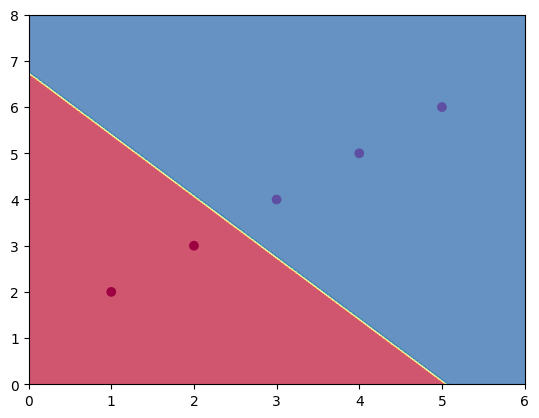

In [96]:
import matplotlib.pyplot as plt

# create 2D dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression(lr=0.1, n_iters=1000, reg_type='l2', reg_strength=0.1, batch_size=4)

# train model on dataset
lr.fit(X, y)

# plot decision boundary
x1 = np.linspace(0, 6, 100)
x2 = np.linspace(0, 8, 100)
xx, yy = np.meshgrid(x1, x2)
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# plot data points
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)

plt.show()